# Project 01 — Numerical Modeling of Solar Wind ODEs

## 1. Theoretical Background

The Parker solar wind model describes the radial expansion of plasma from the Sun using a spherically symmetric and isothermal hydrodynamic model.

The model is based on three main equations: conservation of momentum, conservation of mass, and the isothermal equation of state.

### Momentum Equation

The radial momentum equation is

$$
v\frac{dv}{dr}
+\frac{1}{\rho}\frac{dP}{dr}
+\frac{GM_\odot}{r^2}=0,
$$

where $v$ is the radial velocity of the solar wind, $\rho$ is the plasma density, $P$ is the pressure, $G$ is the gravitational constant, and $M_\odot$ is the solar mass.

The term

$$
v\frac{dv}{dr}
$$

represents the advective acceleration of the plasma.

### Continuity Equation

For a steady and spherically symmetric flow,

$$
4\pi r^2\rho v=\dot{M},
$$

where $\dot{M}$ is the constant solar mass-loss rate.

### Isothermal Equation of State

For an isothermal plasma,

$$
P=\frac{RT}{\mu}\rho,
$$

or equivalently,

$$
P=\frac{k_B T}{\mu m_p}\rho.
$$

These equations can be combined to obtain the differential equation governing the velocity of the Parker solar wind.

## 2. Derivation of the Parker Wind Equation

From the continuity equation,

$$
4\pi r^2\rho v=\dot{M},
$$

and since $\dot{M}$ is constant,

$$
r^2\rho v=\text{constant}.
$$

Taking the logarithmic derivative with respect to $r$ gives

$$
\frac{1}{\rho}\frac{d\rho}{dr}
+\frac{1}{v}\frac{dv}{dr}
+\frac{2}{r}=0.
$$

Therefore,

$$
\frac{1}{\rho}\frac{d\rho}{dr}
=
-\frac{1}{v}\frac{dv}{dr}
-\frac{2}{r}.
$$

For an isothermal plasma,

$$
P=v_c^2\rho,
$$

where the isothermal sound speed is

$$
v_c^2=\frac{k_B T}{\mu m_p}.
$$

Since the temperature is constant,

$$
\frac{1}{\rho}\frac{dP}{dr}
=
v_c^2\frac{1}{\rho}\frac{d\rho}{dr}.
$$

Substituting the continuity relation into the momentum equation,

$$
v\frac{dv}{dr}
+\frac{1}{\rho}\frac{dP}{dr}
+\frac{GM_\odot}{r^2}=0,
$$

gives

$$
v\frac{dv}{dr}
-
v_c^2
\left(
\frac{1}{v}\frac{dv}{dr}
+\frac{2}{r}
\right)
+\frac{GM_\odot}{r^2}=0.
$$

Collecting the terms containing $dv/dr$,

$$
\left(
v-\frac{v_c^2}{v}
\right)
\frac{dv}{dr}
=
\frac{2v_c^2}{r}
-\frac{GM_\odot}{r^2}.
$$

Thus, the Parker solar wind equation can be written as

$$
\boxed{
\frac{dv}{dr}
=
\frac{
\frac{2v_c^2}{r}-\frac{GM_\odot}{r^2}
}{
v-\frac{v_c^2}{v}
}
}
$$

$$
\boxed{
v_c=\sqrt{\frac{k_B T}{\mu m_p}}
}.
$$

## 3. Critical Point of the Parker Wind
### The sonic point

The solar wind begins in a subsonic regime close to the Sun and can evolve into a supersonic flow. Therefore, a physically important point occurs when the wind velocity becomes equal to the sound speed,

$$
v=v_c.
$$

At this point, the denominator of the Parker equation becomes

$$
v_c-\frac{v_c^2}{v_c}
=
v_c-v_c
=
0.
$$

Thus, directly evaluating the differential equation at the sonic point would produce a singularity unless the numerator also becomes zero.

For the transonic solution to pass continuously through this point, we therefore require

$$
\frac{2v_c^2}{r_c}
-\frac{GM_\odot}{r_c^2}
=0,
$$

where $r_c$ is the critical radius.

Multiplying by $r_c^2$,

$$
2v_c^2r_c-GM_\odot=0.
$$

Therefore,

$$
2v_c^2r_c=GM_\odot,
$$

and the critical radius is

$$
\boxed{
r_c=\frac{GM_\odot}{2v_c^2}
}.
$$

The point

$$
(r_c,v_c)
$$

is therefore the **critical or sonic point** of the Parker solar wind model. At this point, both the numerator and denominator of the differential equation vanish. It separates the subsonic and supersonic regions of the transonic solar wind solution.

For the baseline model, we use

$$
T=10^6\ \mathrm{K},
\qquad
\mu=0.5,
$$

and calculate $v_c$ and $r_c$ numerically using the solar parameters provided in the project.

In [1]:
import numpy as np

# Constantes
G = 6.67430e-11
M_sun = 1.989e30
k_B = 1.380649e-23
m_p = 1.6726219e-27
mu = 0.5
R_sun = 6.96e8

# Temperatura
T = 1e6

# Velocidad sonica
v_c = np.sqrt((k_B*T)/(mu*m_p))

# Radio critico
r_c = (G*M_sun)/(2*v_c**2)

print(f"Velocidad sonica: {v_c/1000} km/s")
print(f"Radio critico: {r_c/R_sun} R_sun")

Velocidad sonica: 128.48657419073416 km/s
Radio critico: 5.776779249267315 R_sun


### Physical Role of the Advection Term

The momentum equation of the Parker solar wind is

$$
v\frac{dv}{dr}
+
\frac{1}{\rho}\frac{dP}{dr}
+
\frac{GM_\odot}{r^2}
=0.
$$

The first term,

$$
v\frac{dv}{dr},
$$

represents the **advective acceleration** of the plasma. It describes the change in velocity experienced by the fluid as it moves radially away from the Sun.

Rearranging the momentum equation,

$$
v\frac{dv}{dr}
=
-\frac{1}{\rho}\frac{dP}{dr}
-\frac{GM_\odot}{r^2},
$$

shows the competition between two main effects:

- The pressure gradient can accelerate the plasma outward.
- Solar gravity acts inward and opposes the expansion.

Therefore, the advection term represents the resulting acceleration of the moving plasma under these forces.

After combining the momentum, continuity, and isothermal equations, this competition is expressed by the Parker equation,

$$
\left(
v-\frac{v_c^2}{v}
\right)\frac{dv}{dr}
=
\frac{2v_c^2}{r}
-\frac{GM_\odot}{r^2}.
$$

This equation allows a special **transonic solution** in which the solar wind starts with

$$
v<v_c,
$$

passes continuously through the critical point

$$
v=v_c
\qquad \text{at} \qquad
r=r_c,
$$

and then reaches the supersonic regime

$$
v>v_c.
$$

Thus, the advective term is essential because it describes the radial acceleration of the plasma and allows the model to represent a solar wind that transitions from a subsonic flow near the Sun to an accelerating supersonic outflow at larger distances.

## 4. Semi-Analytical Solution of the Parker Wind

The Parker wind equation is

$$
\left(
v-\frac{v_c^2}{v}
\right)\frac{dv}{dr}
=
\frac{2v_c^2}{r}
-\frac{GM_\odot}{r^2}.
$$

Using the critical-radius relation

$$
r_c=\frac{GM_\odot}{2v_c^2},
$$

we have

$$
GM_\odot=2v_c^2r_c.
$$

Substituting this expression into the Parker equation gives

$$
\left(
v-\frac{v_c^2}{v}
\right)\frac{dv}{dr}
=
\frac{2v_c^2}{r}
-\frac{2v_c^2r_c}{r^2}.
$$

To obtain an integrated relation between velocity and radius, we integrate both sides with respect to $r$:

$$
\int
\left(
v-\frac{v_c^2}{v}
\right)dv
=
\int
\left(
\frac{2v_c^2}{r}
-\frac{2v_c^2r_c}{r^2}
\right)dr.
$$

The left-hand side becomes

$$
\frac{v^2}{2}-v_c^2\ln(v),
$$

while the right-hand side becomes

$$
2v_c^2\ln(r)+\frac{2v_c^2r_c}{r}+C.
$$

The integration constant can be determined by requiring the solution to pass through the critical point

$$
(r,v)=(r_c,v_c).
$$

After applying this condition and expressing the equation in dimensionless form, the integrated Parker wind equation becomes

$$
\boxed{
\left(\frac{v}{v_c}\right)^2
-
\ln\left(\frac{v}{v_c}\right)^2
=
4\ln\left(\frac{r}{r_c}\right)
+
4\frac{r_c}{r}
-3
}
$$

This equation gives an implicit relation between $v$ and $r$.

### Why is a root-finding method necessary?

Although the previous equation provides the analytical relation between velocity and radius, the velocity $v$ cannot be directly isolated using elementary algebraic operations.

For a given value of $r$, we therefore define

$$
F(v;r)=
\left(\frac{v}{v_c}\right)^2
-
\ln\left(\frac{v}{v_c}\right)^2
-
4\ln\left(\frac{r}{r_c}\right)
-
4\frac{r_c}{r}
+3.
$$

The solar wind velocity at each radius is then obtained by solving

$$
\boxed{F(v;r)=0}.
$$

Therefore, a numerical root-finding method can be applied at each value of $r$ to determine $v(r)$.

The physical transonic solution has two branches:

$$
v<v_c \qquad \text{for} \qquad r<r_c,
$$

and

$$
v>v_c \qquad \text{for} \qquad r>r_c.
$$

Both branches meet at the critical point

$$
v=v_c,
\qquad
r=r_c.
$$

### Numerical Root Finding with the Bisection Method

For each radius $r$, the solar wind velocity is obtained by solving

$$
F(v;r)=0,
$$

where

$$
F(v;r)=
\left(\frac{v}{v_c}\right)^2
-\ln\left(\frac{v}{v_c}\right)^2
-4\ln\left(\frac{r}{r_c}\right)
-4\frac{r_c}{r}
+3.
$$

The bisection method searches for a root inside an interval $[a,b]$ where

$$
F(a)F(b)<0.
$$

At each iteration, the midpoint

$$
c=\frac{a+b}{2}
$$

is calculated. The interval containing the root is retained and the process is repeated until the desired tolerance is reached.

For the Parker wind, the interval must be selected according to the physical branch of the solution:

- For $r<r_c$, the subsonic solution satisfies $0<v<v_c$.
- For $r>r_c$, the supersonic solution satisfies $v>v_c$.
- At $r=r_c$, the solution is exactly $v=v_c$.

In this way, the root-finding procedure follows the physical transonic solution through the critical point.

In [2]:
# Funcion implicita de Parker
def F(v,r):
  return (v/v_c)**2 - np.log((v/v_c)**2) - 4*np.log(r/r_c) - 4*r_c/r + 3

In [3]:
# Metodo de biseccion
def biseccion(r,a,b,tol=1e-6,max_iter=1000):

  for i in range(max_iter):

    c = (a+b)/2

    if abs(F(c,r)) < tol:
      return c

    if F(a,r)*F(c,r) < 0:
      b = c
    else:
      a = c

  return c

In [4]:
# Prueba para r = 2 R_sun
r_prueba = 2*R_sun

v_prueba = biseccion(r_prueba,1,v_c*(1-1e-6))

print(f"Velocidad en r = 2 R_sun: {v_prueba/1000} km/s")

Velocidad en r = 2 R_sun: 14.987952304832008 km/s


### Construction of the Transonic Solution

The previous calculation obtained the subsonic solution at a single radius. We now repeat the root-finding procedure over a range of radial positions.

For each value of $r$, the appropriate root must be selected:

$$
r<r_c \quad \Longrightarrow \quad 0<v<v_c,
$$

and

$$
r>r_c \quad \Longrightarrow \quad v>v_c.
$$

At the critical point,

$$
r=r_c,
\qquad
v=v_c.
$$

Therefore, the complete transonic solution is constructed by finding the subsonic root below the critical radius and the supersonic root above it.

In [5]:
# Dominio radial
r = np.linspace(1*R_sun,100*R_sun,1000)

# Arreglo para guardar las velocidades
v_analitica = np.zeros(len(r))

In [6]:
for i in range(len(r)):

  if r[i] < r_c:

    # Rama subsonica
    v_analitica[i] = biseccion(r[i],1,v_c*(1-1e-6))

  elif r[i] > r_c:

    # Rama supersonica
    a = v_c*(1+1e-6)
    b = 10*v_c

    v_analitica[i] = biseccion(r[i],a,b)

  else:

    # Punto critico
    v_analitica[i] = v_c

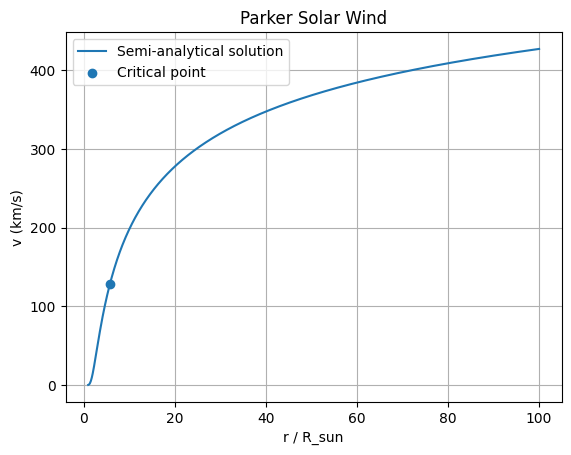

In [7]:
import matplotlib.pyplot as plt

plt.plot(r/R_sun,v_analitica/1000,label="Semi-analytical solution")

plt.scatter(r_c/R_sun,v_c/1000,label="Critical point")

plt.xlabel("r / R_sun")
plt.ylabel("v (km/s)")
plt.title("Parker Solar Wind")
plt.legend()
plt.grid()

plt.show()

In [11]:
# Velocidad a grandes distancias
v_100 = v_analitica[-1]/1000

print(f"Velocidad en r = 100 R_sun: {v_100} km/s")

Velocidad en r = 100 R_sun: 426.87104293548896 km/s


### Comparison with Observed Solar Wind Speeds

At large radial distances, the Parker solution approaches velocities of several hundred km/s. At $r=100R_\odot$, the numerical value obtained from the semi-analytical solution is approximately

$$
v(100R_\odot)\approx 426.871\ \mathrm{km/s}.
$$

This value is close to the characteristic observed speed of the slow solar wind,

$$
v_{\mathrm{slow}}\sim400\ \mathrm{km/s}.
$$

Therefore, despite the simplifying assumptions of an isothermal and spherically symmetric model, the Parker solution produces a large-distance wind velocity of the same order of magnitude as the observed slow solar wind.

The result also shows that the wind continues accelerating after crossing the critical point, eventually reaching velocities comparable to those measured in the solar wind.

### Semi-Analytical Solution Results

The obtained solution shows the expected transonic behavior of the Parker solar wind. Close to the Sun, the flow is subsonic and its velocity increases rapidly with radial distance.

The solution passes through the critical point

$$
(r,v)=(r_c,v_c),
$$

where the wind velocity becomes equal to the isothermal sound speed. Beyond this point, the flow becomes supersonic and continues accelerating as it moves away from the Sun.

At large radial distances, the velocity reaches values of several hundred km/s, comparable to typical observed solar wind velocities.

This semi-analytical solution will be used as a reference to evaluate the numerical solutions obtained with the Euler and RK4 methods.

## 5. Numerical Solution of the Parker Wind ODE

We now solve the Parker wind equation directly as a first-order ordinary differential equation,

$$
\frac{dv}{dr}=f(r,v),
$$

where

$$
f(r,v)=
\frac{
\frac{2v_c^2}{r}-\frac{GM_\odot}{r^2}
}{
v-\frac{v_c^2}{v}
}.
$$

Unlike the previous semi-analytical approach, where the integrated equation was solved independently at each radius using a root-finding method, we now obtain the velocity by numerically integrating the differential equation.

### The Critical-Point Problem

At the critical point,

$$
r=r_c,
\qquad
v=v_c.
$$

The numerator of the differential equation becomes

$$
\frac{2v_c^2}{r_c}
-\frac{GM_\odot}{r_c^2}=0,
$$

while the denominator becomes

$$
v_c-\frac{v_c^2}{v_c}=0.
$$

Therefore, direct numerical evaluation at the critical point produces the indeterminate form

$$
\frac{dv}{dr}=\frac{0}{0}.
$$

For this reason, the numerical integration cannot start exactly at $(r_c,v_c)$.

Instead, the transonic solution is divided into two branches:

- The **subsonic branch** starts slightly below the critical point and is integrated backward toward the Sun.
- The **supersonic branch** starts slightly above the critical point and is integrated forward away from the Sun.

Following the project specification, small perturbations of order

$$
\epsilon_r=10^{-3}r_c,
\qquad
\epsilon_v=10^{-3}v_c
$$

are used to define the initial conditions around the critical point.

Thus, for the subsonic branch,

$$
r_0=r_c-\epsilon_r,
\qquad
v_0=v_c-\epsilon_v,
$$

while for the supersonic branch,

$$
r_0=r_c+\epsilon_r,
\qquad
v_0=v_c+\epsilon_v.
$$

The two numerical solutions can then be combined to reconstruct the complete transonic solar wind solution.

In [8]:
# Ecuacion diferencial de Parker
def parker_ode(r,v):
  numerador = (2*v_c**2)/r - (G*M_sun)/(r**2)
  denominador = v - (v_c**2)/v

  return numerador/denominador

### Euler Method

For an ODE of the form

$$
\frac{dv}{dr}=f(r,v),
$$

the Euler method approximates the solution using

$$
v_{n+1}=v_n+h\,f(r_n,v_n),
$$

and

$$
r_{n+1}=r_n+h.
$$

The value $f(r_n,v_n)$ represents the local slope of the solution at the current point. Euler's method assumes that this slope remains approximately constant over one step of size $h$.

For the supersonic branch, the integration proceeds outward and therefore

$$
h>0.
$$

For the subsonic branch, the integration proceeds from the critical point toward smaller radii, so the radial step is negative,

$$
h<0.
$$

Euler's method is a first-order method, so its global numerical error is of order

$$
O(h).
$$

Consequently, reducing the step size should improve the approximation, although it increases the number of iterations.

In [10]:
# Metodo de Euler
def euler(r_0,v_0,r_final,h):

  r_valores = [r_0]
  v_valores = [v_0]

  r_actual = r_0
  v_actual = v_0

  if r_final < r_0:
    h = -abs(h)
  else:
    h = abs(h)

  while (h > 0 and r_actual < r_final) or (h < 0 and r_actual > r_final):

    v_nuevo = v_actual + h*parker_ode(r_actual,v_actual)
    r_nuevo = r_actual + h

    r_valores.append(r_nuevo)
    v_valores.append(v_nuevo)

    r_actual = r_nuevo
    v_actual = v_nuevo

  return np.array(r_valores), np.array(v_valores)

### Initial Conditions Around the Critical Point

Since the ODE cannot be evaluated exactly at

$$
(r_c,v_c),
$$

we start the numerical integration slightly away from the critical point.

We define the perturbations

$$
\epsilon_r=10^{-3}r_c,
\qquad
\epsilon_v=10^{-3}v_c.
$$

For the subsonic branch, the initial condition is

$$
r_{\mathrm{sub}}=r_c-\epsilon_r,
\qquad
v_{\mathrm{sub}}=v_c-\epsilon_v,
$$

and the integration proceeds backward toward smaller values of $r$.

For the supersonic branch,

$$
r_{\mathrm{sup}}=r_c+\epsilon_r,
\qquad
v_{\mathrm{sup}}=v_c+\epsilon_v,
$$

and the integration proceeds forward toward larger values of $r$.

For the baseline numerical solution, we use a radial step size

$$
h=10^6\ \mathrm{m}.
$$

In [12]:
# Perturbaciones alrededor del punto critico
epsilon_r = 1e-3*r_c
epsilon_v = 1e-3*v_c

# Rama subsonica
r_sub_0 = r_c - epsilon_r
v_sub_0 = v_c - epsilon_v

# Rama supersonica
r_sup_0 = r_c + epsilon_r
v_sup_0 = v_c + epsilon_v

# Paso
h = 1e6

In [13]:
# Limites de integracion
r_min = 1.5*R_sun
r_max = 100*R_sun

# Rama subsonica: integracion hacia atras
r_sub_euler, v_sub_euler = euler(r_sub_0,v_sub_0,r_min,h)

# Rama supersonica: integracion hacia adelante
r_sup_euler, v_sup_euler = euler(r_sup_0,v_sup_0,r_max,h)

In [14]:
# Unir las dos ramas
r_euler = np.concatenate((r_sub_euler[::-1],[r_c],r_sup_euler))
v_euler = np.concatenate((v_sub_euler[::-1],[v_c],v_sup_euler))

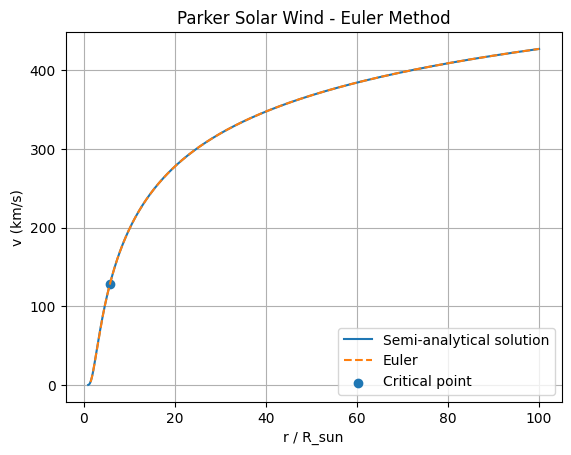

In [16]:
plt.plot(r/R_sun,v_analitica/1000,label="Semi-analytical solution")
plt.plot(r_euler/R_sun,v_euler/1000,"--",label="Euler")

plt.scatter(r_c/R_sun,v_c/1000,label="Critical point")

plt.xlabel("r / R_sun")
plt.ylabel("v (km/s)")
plt.title("Parker Solar Wind - Euler Method")
plt.legend()
plt.grid()

plt.show()

### Runge-Kutta Fourth-Order Method

Euler's method estimates the next value using only the slope at the beginning of each step. The fourth-order Runge-Kutta method (RK4) improves this approximation by evaluating the slope at four different points within the interval.

For an ODE

$$
\frac{dv}{dr}=f(r,v),
$$

the four increments are

$$
k_1=h\,f(r_n,v_n),
$$

$$
k_2=h\,f\left(r_n+\frac{h}{2},v_n+\frac{k_1}{2}\right),
$$

$$
k_3=h\,f\left(r_n+\frac{h}{2},v_n+\frac{k_2}{2}\right),
$$

and

$$
k_4=h\,f(r_n+h,v_n+k_3).
$$

The velocity is then updated using the weighted average

$$
v_{n+1}
=
v_n+
\frac{k_1+2k_2+2k_3+k_4}{6},
$$

while the radial coordinate is updated as

$$
r_{n+1}=r_n+h.
$$

RK4 is a fourth-order method, with global error of order

$$
O(h^4),
$$

which generally provides substantially better accuracy than the first-order Euler method for the same step size.

As with Euler's method, the integration is performed separately on the subsonic and supersonic branches to avoid evaluating the Parker ODE exactly at the critical point.

In [17]:
# Metodo RK4
def rk4(r_0,v_0,r_final,h):

  r_valores = [r_0]
  v_valores = [v_0]

  r_actual = r_0
  v_actual = v_0

  if r_final < r_0:
    h = -abs(h)
  else:
    h = abs(h)

  while (h > 0 and r_actual < r_final) or (h < 0 and r_actual > r_final):

    k1 = h*parker_ode(r_actual,v_actual)

    k2 = h*parker_ode(r_actual+h/2,
                      v_actual+k1/2)

    k3 = h*parker_ode(r_actual+h/2,
                      v_actual+k2/2)

    k4 = h*parker_ode(r_actual+h,
                      v_actual+k3)

    v_nuevo = v_actual + (k1+2*k2+2*k3+k4)/6
    r_nuevo = r_actual + h

    r_valores.append(r_nuevo)
    v_valores.append(v_nuevo)

    r_actual = r_nuevo
    v_actual = v_nuevo

  return np.array(r_valores), np.array(v_valores)

In [18]:
# Rama subsonica
r_sub_rk4, v_sub_rk4 = rk4(r_sub_0,v_sub_0,r_min,h)

# Rama supersonica
r_sup_rk4, v_sup_rk4 = rk4(r_sup_0,v_sup_0,r_max,h)

In [19]:
# Unir las dos ramas
r_rk4 = np.concatenate((r_sub_rk4[::-1],[r_c],r_sup_rk4))
v_rk4 = np.concatenate((v_sub_rk4[::-1],[v_c],v_sup_rk4))

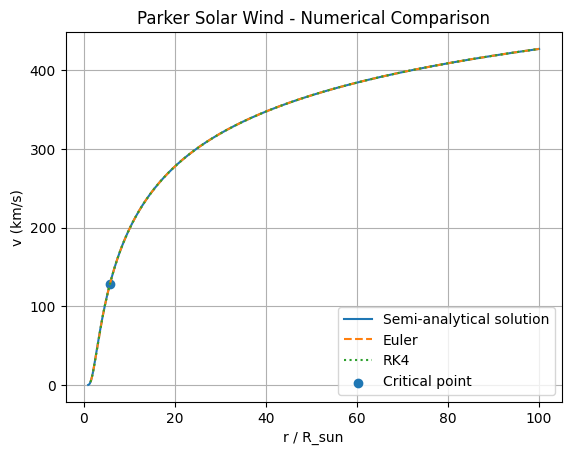

In [20]:
plt.plot(r/R_sun,v_analitica/1000,label="Semi-analytical solution")
plt.plot(r_euler/R_sun,v_euler/1000,"--",label="Euler")
plt.plot(r_rk4/R_sun,v_rk4/1000,":",label="RK4")

plt.scatter(r_c/R_sun,v_c/1000,label="Critical point")

plt.xlabel("r / R_sun")
plt.ylabel("v (km/s)")
plt.title("Parker Solar Wind - Numerical Comparison")
plt.legend()
plt.grid()

plt.show()

### Relative Error at $50R_\odot$

Although the semi-analytical, Euler, and RK4 solutions appear almost identical in the previous plot, small numerical differences cannot be evaluated accurately from visual inspection alone.

To quantify the accuracy of the numerical methods, we compare their velocities at

$$
r=50R_\odot.
$$

Using the semi-analytical solution as the reference, the relative error is defined as

$$
E_{\mathrm{rel}}
=
\frac{
|v_{\mathrm{numerical}}-v_{\mathrm{analytical}}|
}{
|v_{\mathrm{analytical}}|
}
\times100\%.
$$

The relative errors of Euler and RK4 are calculated using the same step size, $h=10^6$ m, allowing a direct comparison between both numerical methods.

In [21]:
# Radio donde queremos comparar
r_50 = 50*R_sun

# Indices mas cercanos a 50 R_sun
indice_analitica = np.argmin(np.abs(r-r_50))
indice_euler = np.argmin(np.abs(r_euler-r_50))
indice_rk4 = np.argmin(np.abs(r_rk4-r_50))

# Velocidades
v_50_analitica = v_analitica[indice_analitica]
v_50_euler = v_euler[indice_euler]
v_50_rk4 = v_rk4[indice_rk4]

print(f"Solucion semi-analitica: {v_50_analitica/1000} km/s")
print(f"Euler: {v_50_euler/1000} km/s")
print(f"RK4: {v_50_rk4/1000} km/s")

Solucion semi-analitica: 367.82210053750083 km/s
Euler: 367.90850165484693 km/s
RK4: 367.90269131075996 km/s


In [22]:
# Errores relativos
error_euler = abs(v_50_euler-v_50_analitica)/abs(v_50_analitica)*100
error_rk4 = abs(v_50_rk4-v_50_analitica)/abs(v_50_analitica)*100

print(f"Error relativo de Euler: {error_euler} %")
print(f"Error relativo de RK4: {error_rk4} %")

Error relativo de Euler: 0.02348992005099057 %
Error relativo de RK4: 0.02191025855743995 %


### Relative Error at $50R_\odot$

To quantitatively compare the numerical methods, the velocity obtained with Euler and RK4 is evaluated at

$$
r=50R_\odot.
$$

The semi-analytical Parker solution is used as the reference, and the relative error is calculated as

$$
E_{\mathrm{rel}}
=
\frac{
|v_{\mathrm{numerical}}-v_{\mathrm{analytical}}|
}{
|v_{\mathrm{analytical}}|
}
\times100\%.
$$

However, the numerical grids generated by Euler and RK4 do not necessarily contain a point located exactly at $50R_\odot$. Simply selecting the closest point would mean comparing velocities evaluated at slightly different radial positions.

To avoid this problem, the numerical solutions are interpolated exactly at $50R_\odot$.

#### Newton Interpolation

For each numerical solution, we select the two consecutive points that surround the desired radius,

$$
(r_0,v_0),\qquad(r_1,v_1),
$$

such that

$$
r_0\leq 50R_\odot\leq r_1.
$$

Using a first-order Newton interpolation polynomial,

$$
P_1(r)
=
a_0+a_1(r-r_0),
$$

where the first coefficient is

$$
a_0=v_0,
$$

and the first divided difference is

$$
a_1=v[r_0,r_1]
=
\frac{v_1-v_0}{r_1-r_0}.
$$

Therefore, the interpolated velocity at $r=50R_\odot$ is

$$
\boxed{
v(50R_\odot)
\approx
v_0+
\frac{v_1-v_0}{r_1-r_0}
(50R_\odot-r_0)
}.
$$

This procedure allows the Euler and RK4 solutions to be compared with the semi-analytical solution at exactly the same radial position.

In [26]:
# Radio donde queremos comparar
r_50 = 50*R_sun

# Solucion semi-analitica exactamente en 50 R_sun
v_50_analitica = biseccion(r_50,v_c*(1+1e-6),10*v_c)

print(f"Solucion semi-analitica en 50 R_sun: {v_50_analitica/1000} km/s")

Solucion semi-analitica en 50 R_sun: 367.90357055161815 km/s


In [27]:
# Interpolacion de Newton de primer grado
def interpolacion_newton(x0,y0,x1,y1,x):

  a0 = y0
  a1 = (y1-y0)/(x1-x0)

  return a0 + a1*(x-x0)

In [28]:
# Indice inmediatamente anterior a 50 R_sun
indice_euler = np.where(r_euler <= r_50)[0][-1]

r0_euler = r_euler[indice_euler]
r1_euler = r_euler[indice_euler+1]

v0_euler = v_euler[indice_euler]
v1_euler = v_euler[indice_euler+1]

print("Puntos de Euler:")
print(r0_euler/R_sun,v0_euler/1000)
print(r1_euler/R_sun,v1_euler/1000)

Puntos de Euler:
49.99951005150509 367.90850165484693
50.000946833114284 367.9110994132101


In [29]:
indice_rk4 = np.where(r_rk4 <= r_50)[0][-1]

r0_rk4 = r_rk4[indice_rk4]
r1_rk4 = r_rk4[indice_rk4+1]

v0_rk4 = v_rk4[indice_rk4]
v1_rk4 = v_rk4[indice_rk4+1]

print("Puntos de RK4:")
print(r0_rk4/R_sun,v0_rk4/1000)
print(r1_rk4/R_sun,v1_rk4/1000)

Puntos de RK4:
49.99951005150509 367.90269131075996
50.000946833114284 367.9052890773796


In [30]:
v_50_euler = interpolacion_newton(
    r0_euler,v0_euler,
    r1_euler,v1_euler,
    r_50
)

v_50_rk4 = interpolacion_newton(
    r0_rk4,v0_rk4,
    r1_rk4,v1_rk4,
    r_50
)

print(f"Solucion semi-analitica: {v_50_analitica/1000} km/s")
print(f"Euler: {v_50_euler/1000} km/s")
print(f"RK4: {v_50_rk4/1000} km/s")

Solucion semi-analitica: 367.90357055161815 km/s
Euler: 367.90938750123587 km/s
RK4: 367.9035771599644 km/s


In [32]:
# Errores relativos
error_euler = abs(v_50_euler-v_50_analitica)/abs(v_50_analitica)*100
error_rk4 = abs(v_50_rk4-v_50_analitica)/abs(v_50_analitica)*100

print(f"Error relativo de Euler: {error_euler} %")
print(f"Error relativo de RK4: {error_rk4} %")

Error relativo de Euler: 0.0015811071387636317 %
Error relativo de RK4: 1.796216952344245e-06 %


### Numerical Comparison at $50R_\odot$

Evaluating all three solutions at exactly $50R_\odot$ gives

$$
v_{\mathrm{analytical}} = 367.903571\ \mathrm{km/s},
$$

$$
v_{\mathrm{Euler}} = 367.909388\ \mathrm{km/s},
$$

and

$$
v_{\mathrm{RK4}} = 367.903577\ \mathrm{km/s}.
$$

The corresponding relative errors are

$$
E_{\mathrm{Euler}}\approx 1.58\times10^{-3}\%,
$$

and

$$
E_{\mathrm{RK4}}\approx 1.80\times10^{-6}\%.
$$

Although the three curves appear almost indistinguishable in the graphical comparison, the numerical errors reveal a clear difference in accuracy. For the same step size, $h=10^6$ m, RK4 produces a substantially smaller error than Euler.

This behavior is consistent with the order of the numerical methods. Euler is a first-order method with global error

$$
O(h),
$$

while RK4 is a fourth-order method with global error

$$
O(h^4).
$$

Therefore, RK4 can achieve much higher accuracy than Euler for the same step size. In this case, both methods provide accurate approximations of the Parker wind solution, but RK4 reproduces the semi-analytical reference much more closely.

## 6. Step-Size Sensitivity and Numerical Stability

The accuracy of a numerical ODE solver depends not only on the integration method but also on the selected step size $h$.

For Euler's method, the global error is

$$
O(h),
$$

while for RK4 it is

$$
O(h^4).
$$

Therefore, decreasing $h$ should improve the numerical approximation for both methods, but the error is expected to decrease much faster for RK4.

The Parker wind equation presents an additional numerical difficulty near the critical point. The ODE is

$$
\frac{dv}{dr}
=
\frac{
\frac{2v_c^2}{r}-\frac{GM_\odot}{r^2}
}{
v-\frac{v_c^2}{v}
}.
$$

Near

$$
(r_c,v_c),
$$

both the numerator and denominator approach zero. Consequently, the numerical evaluation of the derivative becomes particularly sensitive to small changes in $r$ and $v$.

A large step size may therefore produce inaccurate approximations near the critical region and propagate these errors throughout the numerical solution.

To study this effect, Euler and RK4 will be evaluated using different values of $h$, and their relative errors at $50R_\odot$ will be compared with the semi-analytical solution.

In [36]:
# Diferentes tamaños de paso
h_valores = [5e5,1e6,5e6,1e7]

In [37]:
# Evaluar una solucion numerica en 50 R_sun
def velocidad_en_50(r_valores,v_valores):

  indice = np.where(r_valores <= r_50)[0][-1]

  r0 = r_valores[indice]
  r1 = r_valores[indice+1]

  v0 = v_valores[indice]
  v1 = v_valores[indice+1]

  return interpolacion_newton(r0,v0,r1,v1,r_50)

In [38]:
errores_euler = []
errores_rk4 = []

for h_prueba in h_valores:

  # Euler
  r_sub, v_sub = euler(r_sub_0,v_sub_0,r_min,h_prueba)
  r_sup, v_sup = euler(r_sup_0,v_sup_0,r_max,h_prueba)

  r_e = np.concatenate((r_sub[::-1],[r_c],r_sup))
  v_e = np.concatenate((v_sub[::-1],[v_c],v_sup))

  # RK4
  r_sub, v_sub = rk4(r_sub_0,v_sub_0,r_min,h_prueba)
  r_sup, v_sup = rk4(r_sup_0,v_sup_0,r_max,h_prueba)

  r_r = np.concatenate((r_sub[::-1],[r_c],r_sup))
  v_r = np.concatenate((v_sub[::-1],[v_c],v_sup))

  # Velocidad exactamente en 50 R_sun
  v_e_50 = velocidad_en_50(r_e,v_e)
  v_r_50 = velocidad_en_50(r_r,v_r)

  # Errores relativos
  error_e = abs(v_e_50-v_50_analitica)/abs(v_50_analitica)*100
  error_r = abs(v_r_50-v_50_analitica)/abs(v_50_analitica)*100

  errores_euler.append(error_e)
  errores_rk4.append(error_r)

  print(f"h = {h_prueba} m")
  print(f"Error Euler = {error_e} %")
  print(f"Error RK4 = {error_r} %")
  print()

h = 500000.0 m
Error Euler = 0.0007914506479610283 %
Error RK4 = 1.7982649118225028e-06 %

h = 1000000.0 m
Error Euler = 0.0015811071387636317 %
Error RK4 = 1.796216952344245e-06 %

h = 5000000.0 m
Error Euler = 0.007898580528217652 %
Error RK4 = 1.7798525153952509e-06 %

h = 10000000.0 m
Error Euler = 0.015795716716266263 %
Error RK4 = 1.500322564201586e-06 %



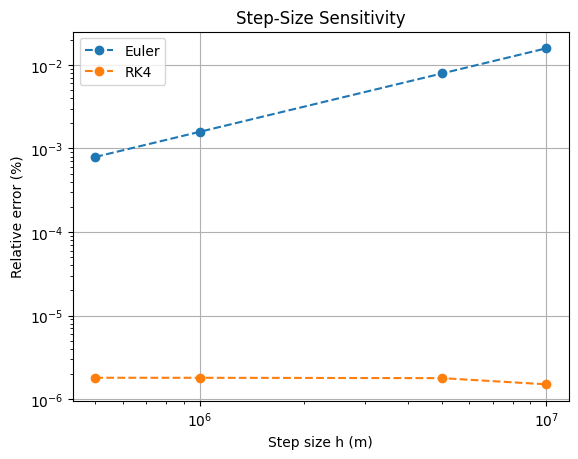

In [39]:
plt.loglog(h_valores,errores_euler,"o--",label="Euler")
plt.loglog(h_valores,errores_rk4,"o--",label="RK4")

plt.xlabel("Step size h (m)")
plt.ylabel("Relative error (%)")
plt.title("Step-Size Sensitivity")
plt.legend()
plt.grid()

plt.show()

### Step-Size Analysis

The step-size study shows a clear difference between Euler and RK4.

For Euler's method, the relative error increases approximately in direct proportion to the step size. For example, reducing the step size from

$$
h=10^6\ \mathrm{m}
$$

to

$$
h=5\times10^5\ \mathrm{m}
$$

reduces the relative error from approximately

$$
1.58\times10^{-3}\%
$$

to

$$
7.91\times10^{-4}\%.
$$

The error is therefore reduced by approximately a factor of two when the step size is divided by two. This behavior is consistent with the first-order convergence of Euler's method,

$$
E_{\mathrm{Euler}}\propto h.
$$

For RK4, the relative error remains approximately of order

$$
10^{-6}\%
$$

for all the tested step sizes. Therefore, the expected fourth-order convergence is not directly visible in this experiment.

This does not imply that RK4 is independent of the step size. Instead, the integration error has become sufficiently small that other numerical effects in the calculation, such as the finite perturbation used to initialize the solution near the critical point and the interpolation at $50R_\odot$, can become comparable to or larger than the RK4 integration error.

Nevertheless, RK4 remains substantially more accurate than Euler throughout the tested range of step sizes. The results also illustrate why smaller steps can be particularly important for lower-order methods and in regions close to the critical point, where the Parker ODE is numerically sensitive.

## 7. Temperature Sensitivity Analysis

The temperature of the solar corona plays an important role in the Parker solar wind model because it determines the isothermal sound speed,

$$
v_c=\sqrt{\frac{k_BT}{\mu m_p}},
$$

and consequently the location of the critical point,

$$
r_c=\frac{GM_\odot}{2v_c^2}.
$$

Since

$$
v_c^2\propto T,
$$

the critical radius satisfies

$$
r_c\propto\frac{1}{T}.
$$

Therefore, increasing the coronal temperature increases the characteristic sound speed and moves the critical point closer to the Sun.

To investigate the effect of temperature on the solar wind, we consider three isothermal coronal temperatures:

$$
T=
0.5\times10^6,\quad
1.0\times10^6,\quad
2.0\times10^6\ \mathrm{K}.
$$

For each temperature, the corresponding sound speed and critical radius are calculated, and the Parker wind equation is integrated using the RK4 method.

In [42]:
# Temperaturas a estudiar
temperaturas = [0.5e6,1e6,2e6]

for T_prueba in temperaturas:

  v_c_prueba = np.sqrt((k_B*T_prueba)/(mu*m_p))
  r_c_prueba = (G*M_sun)/(2*v_c_prueba**2)

  print(f"T = {T_prueba} K")
  print(f"v_c = {v_c_prueba/1000} km/s")
  print(f"r_c = {r_c_prueba/R_sun} R_sun")
  print()

T = 500000.0 K
v_c = 90.85372790169657 km/s
r_c = 11.55355849853463 R_sun

T = 1000000.0 K
v_c = 128.48657419073416 km/s
r_c = 5.776779249267315 R_sun

T = 2000000.0 K
v_c = 181.70745580339315 km/s
r_c = 2.8883896246336573 R_sun



### Effect of Temperature on the Critical Point

The calculated critical parameters are:

| $T$ (K) | $v_c$ (km/s) | $r_c$ ($R_\odot$) |
|---:|---:|---:|
| $0.5\times10^6$ | 90.85 | 11.55 |
| $1.0\times10^6$ | 128.49 | 5.78 |
| $2.0\times10^6$ | 181.71 | 2.89 |

The numerical values confirm the expected dependence

$$
v_c\propto\sqrt{T},
$$

and

$$
r_c\propto\frac{1}{T}.
$$

Therefore, a hotter corona produces a larger characteristic sound speed and causes the transonic transition to occur closer to the Sun. In contrast, for lower temperatures the critical point moves farther away from the solar surface.

In [43]:
# Ecuacion diferencial de Parker generalizada
def parker_ode(r,v,v_c):

  numerador = (2*v_c**2)/r - (G*M_sun)/(r**2)
  denominador = v - (v_c**2)/v

  return numerador/denominador

In [44]:
# Metodo RK4 generalizado
def rk4(r_0,v_0,r_final,h,v_c):

  r_valores = [r_0]
  v_valores = [v_0]

  r_actual = r_0
  v_actual = v_0

  if r_final < r_0:
    h = -abs(h)
  else:
    h = abs(h)

  while (h > 0 and r_actual < r_final) or (h < 0 and r_actual > r_final):

    k1 = h*parker_ode(r_actual,v_actual,v_c)

    k2 = h*parker_ode(r_actual+h/2,
                      v_actual+k1/2,
                      v_c)

    k3 = h*parker_ode(r_actual+h/2,
                      v_actual+k2/2,
                      v_c)

    k4 = h*parker_ode(r_actual+h,
                      v_actual+k3,
                      v_c)

    v_nuevo = v_actual + (k1+2*k2+2*k3+k4)/6
    r_nuevo = r_actual + h

    r_valores.append(r_nuevo)
    v_valores.append(v_nuevo)

    r_actual = r_nuevo
    v_actual = v_nuevo

  return np.array(r_valores), np.array(v_valores)

In [45]:
def solve_parker_wind(T,r_min=1.5,r_max=100,h=1e6):

  # Velocidad sonica y radio critico
  v_c = np.sqrt((k_B*T)/(mu*m_p))
  r_c = (G*M_sun)/(2*v_c**2)

  # Perturbaciones
  epsilon_r = 1e-3*r_c
  epsilon_v = 1e-3*v_c

  # Condiciones iniciales
  r_sub_0 = r_c - epsilon_r
  v_sub_0 = v_c - epsilon_v

  r_sup_0 = r_c + epsilon_r
  v_sup_0 = v_c + epsilon_v

  # Limites en metros
  r_min_m = r_min*R_sun
  r_max_m = r_max*R_sun

  # Rama subsonica
  r_sub, v_sub = rk4(r_sub_0,v_sub_0,r_min_m,h,v_c)

  # Rama supersonica
  r_sup, v_sup = rk4(r_sup_0,v_sup_0,r_max_m,h,v_c)

  # Unir las ramas
  r = np.concatenate((r_sub[::-1],[r_c],r_sup))
  v = np.concatenate((v_sub[::-1],[v_c],v_sup))

  return r,v

In [46]:
r_05, v_05 = solve_parker_wind(0.5e6)
r_10, v_10 = solve_parker_wind(1e6)
r_20, v_20 = solve_parker_wind(2e6)

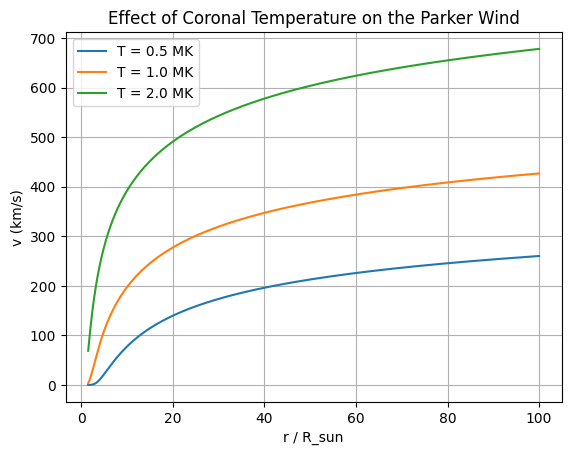

In [47]:
plt.plot(r_05/R_sun,v_05/1000,label="T = 0.5 MK")
plt.plot(r_10/R_sun,v_10/1000,label="T = 1.0 MK")
plt.plot(r_20/R_sun,v_20/1000,label="T = 2.0 MK")

plt.xlabel("r / R_sun")
plt.ylabel("v (km/s)")
plt.title("Effect of Coronal Temperature on the Parker Wind")
plt.legend()
plt.grid()

plt.show()

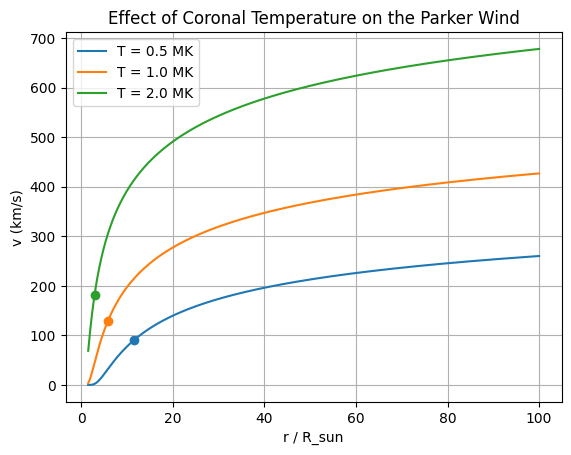

In [48]:
plt.plot(r_05/R_sun,v_05/1000,label="T = 0.5 MK")
plt.plot(r_10/R_sun,v_10/1000,label="T = 1.0 MK")
plt.plot(r_20/R_sun,v_20/1000,label="T = 2.0 MK")

# Puntos criticos
for T_prueba in temperaturas:

  v_c_prueba = np.sqrt((k_B*T_prueba)/(mu*m_p))
  r_c_prueba = (G*M_sun)/(2*v_c_prueba**2)

  plt.scatter(r_c_prueba/R_sun,v_c_prueba/1000)

plt.xlabel("r / R_sun")
plt.ylabel("v (km/s)")
plt.title("Effect of Coronal Temperature on the Parker Wind")
plt.legend()
plt.grid()

plt.show()

In [49]:
# Tasa de perdida de masa solar
segundos_ano = 365.25*24*60*60

M_dot = 2e-14*M_sun/segundos_ano

print(f"M_dot = {M_dot} kg/s")

M_dot = 1260552133.2420716 kg/s


In [50]:
# Densidad
rho_05 = M_dot/(4*np.pi*r_05**2*v_05)
rho_10 = M_dot/(4*np.pi*r_10**2*v_10)
rho_20 = M_dot/(4*np.pi*r_20**2*v_20)

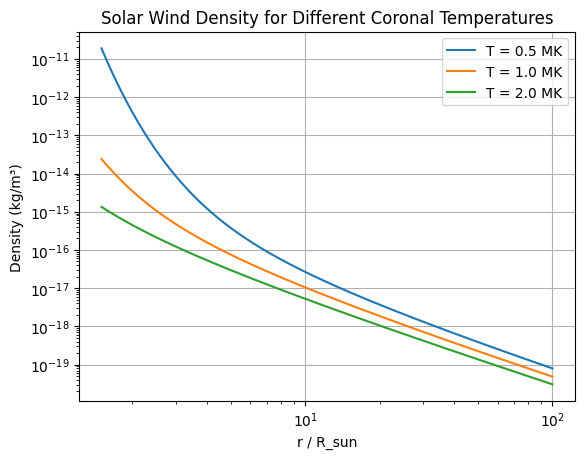

In [51]:
plt.loglog(r_05/R_sun,rho_05,label="T = 0.5 MK")
plt.loglog(r_10/R_sun,rho_10,label="T = 1.0 MK")
plt.loglog(r_20/R_sun,rho_20,label="T = 2.0 MK")

plt.xlabel("r / R_sun")
plt.ylabel("Density (kg/m³)")
plt.title("Solar Wind Density for Different Coronal Temperatures")
plt.legend()
plt.grid()

plt.show()

### Density Profiles

The density profiles decrease rapidly with radial distance for all three temperatures. From mass conservation,

$$
\rho(r)=\frac{\dot{M}}{4\pi r^2v(r)},
$$

so the density decreases because of both the spherical expansion of the wind, represented by the factor $r^{-2}$, and the increase of the wind velocity with radial distance.

At a fixed radius, the hotter solutions have lower densities. Since the same mass-loss rate is used in all three cases, a larger wind velocity must be compensated by a smaller density in order to preserve the constant mass flux

$$
4\pi r^2\rho v=\dot{M}.
$$

Therefore, the $2.0$ MK solution produces the lowest density profile, while the $0.5$ MK solution produces the highest density profile.

In [52]:
# Soluciones hasta 1 AU
r_05_AU, v_05_AU = solve_parker_wind(0.5e6,r_max=215)
r_10_AU, v_10_AU = solve_parker_wind(1e6,r_max=215)
r_20_AU, v_20_AU = solve_parker_wind(2e6,r_max=215)

In [53]:
# Interpolar una solucion numerica en cualquier radio
def velocidad_interpolada(r_valores,v_valores,r_objetivo):

  indice = np.where(r_valores <= r_objetivo)[0][-1]

  r0 = r_valores[indice]
  r1 = r_valores[indice+1]

  v0 = v_valores[indice]
  v1 = v_valores[indice+1]

  return interpolacion_newton(r0,v0,r1,v1,r_objetivo)

In [54]:
# 1 AU
r_AU = 215*R_sun

v_05_1AU = velocidad_interpolada(r_05_AU,v_05_AU,r_AU)
v_10_1AU = velocidad_interpolada(r_10_AU,v_10_AU,r_AU)
v_20_1AU = velocidad_interpolada(r_20_AU,v_20_AU,r_AU)

print(f"T = 0.5 MK: {v_05_1AU/1000} km/s")
print(f"T = 1.0 MK: {v_10_1AU/1000} km/s")
print(f"T = 2.0 MK: {v_20_1AU/1000} km/s")

T = 0.5 MK: 305.9175729360808 km/s
T = 1.0 MK: 484.68558748236154 km/s
T = 2.0 MK: 752.1589671047169 km/s


### Effect of Temperature at 1 AU

To evaluate the effect of coronal temperature at large radial distances, the numerical solutions were extended to

$$
1\ \mathrm{AU}\approx215R_\odot.
$$

The velocities obtained with RK4 are

| $T$ | $v(1\,\mathrm{AU})$ |
|---:|---:|
| $0.5$ MK | $305.92$ km/s |
| $1.0$ MK | $484.69$ km/s |
| $2.0$ MK | $752.16$ km/s |

The results show a strong dependence of the solar wind velocity on coronal temperature. Increasing the temperature increases the isothermal sound speed,

$$
v_c^2=\frac{k_BT}{\mu m_p},
$$

and modifies the balance between pressure-driven expansion and solar gravity in the Parker equation,

$$
\left(
v-\frac{v_c^2}{v}
\right)\frac{dv}{dr}
=
\frac{2v_c^2}{r}
-\frac{GM_\odot}{r^2}.
$$

A larger temperature increases the pressure-related contribution represented by $v_c^2$. As a result, hotter solutions undergo stronger outward acceleration and cross the sonic point closer to the Sun.

The advective term,

$$
v\frac{dv}{dr},
$$

represents the acceleration experienced by the moving plasma. The numerical solutions show that the different pressure conditions associated with temperature lead to different acceleration histories, which accumulate over radial distance and produce substantially different wind velocities at 1 AU.

Thus, within the isothermal Parker model, hotter coronal conditions produce an earlier transonic transition and a faster solar wind at large distances.

### Minimum Temperature for a Transonic Wind

The numerical Parker solver used in this project constructs the solution starting from small perturbations around the critical point $(r_c,v_c)$. Therefore, checking whether the computed solution crosses the sonic velocity would not provide an independent criterion for determining a minimum temperature, since the transonic transition is already incorporated into the numerical initialization.

To define a numerical threshold, we adopt the following criterion: the wind must reach its critical point before 1 AU,

$$
r_c(T)\leq215R_\odot.
$$

Under this criterion, the minimum temperature corresponds approximately to the case in which

$$
r_c(T)\approx215R_\odot.
$$

Rather than solving this condition analytically, a numerical search over temperature is performed to identify the transition between solutions whose critical point lies beyond 1 AU and those whose critical point lies within 1 AU.

In [55]:
# Rango de temperaturas
T_valores = np.linspace(10000,100000,1000)

# Distancia de 1 AU
r_AU = 215*R_sun

T_min = None

for T_prueba in T_valores:

  v_c_prueba = np.sqrt((k_B*T_prueba)/(mu*m_p))
  r_c_prueba = (G*M_sun)/(2*v_c_prueba**2)

  if r_c_prueba <= r_AU:
    T_min = T_prueba
    break

print(f"Temperatura minima aproximada: {T_min} K")

Temperatura minima aproximada: 26936.936936936938 K


In [56]:
v_c_min = np.sqrt((k_B*T_min)/(mu*m_p))
r_c_min = (G*M_sun)/(2*v_c_min**2)

print(f"T_min = {T_min} K")
print(f"v_c = {v_c_min/1000} km/s")
print(f"r_c = {r_c_min/R_sun} R_sun")

T_min = 26936.936936936938 K
v_c = 21.08782818824073 km/s
r_c = 214.45568450457256 R_sun


In [57]:
def funcion_temperatura(T):

  v_c_T = np.sqrt((k_B*T)/(mu*m_p))
  r_c_T = (G*M_sun)/(2*v_c_T**2)

  return r_c_T - 215*R_sun

In [58]:
def biseccion_temperatura(T_a,T_b,tol=1e-6):

  while abs(T_b-T_a) > tol:

    T_medio = (T_a+T_b)/2

    if funcion_temperatura(T_a)*funcion_temperatura(T_medio) < 0:
      T_b = T_medio
    else:
      T_a = T_medio

  return (T_a+T_b)/2

In [59]:
T_min_biseccion = biseccion_temperatura(10000,100000)

v_c_min = np.sqrt((k_B*T_min_biseccion)/(mu*m_p))
r_c_min = (G*M_sun)/(2*v_c_min**2)

print(f"Temperatura minima: {T_min_biseccion} K")
print(f"Velocidad sonica: {v_c_min/1000} km/s")
print(f"Radio critico: {r_c_min/R_sun} R_sun")

Temperatura minima: 26868.74069429905 K
Velocidad sonica: 21.061117244427827 km/s
Radio critico: 214.99999999974017 R_sun


In [60]:
T_inferior = 0.9*T_min_biseccion
T_superior = 1.1*T_min_biseccion

for T_prueba in [T_inferior,T_min_biseccion,T_superior]:

  v_c_prueba = np.sqrt((k_B*T_prueba)/(mu*m_p))
  r_c_prueba = (G*M_sun)/(2*v_c_prueba**2)

  print(f"T = {T_prueba} K")
  print(f"r_c = {r_c_prueba/R_sun} R_sun")
  print()

T = 24181.866624869144 K
r_c = 238.88888888860026 R_sun

T = 26868.74069429905 K
r_c = 214.99999999974017 R_sun

T = 29555.614763728958 K
r_c = 195.45454545430925 R_sun



### Numerical Minimum Temperature

Using the adopted criterion that the critical point must occur before 1 AU,

$$
r_c(T)\leq215R_\odot,
$$

a numerical bisection search was performed in temperature.

The limiting temperature obtained was

$$
\boxed{
T_{\min}\approx2.69\times10^4\ \mathrm{K}
}
$$

with a corresponding sonic velocity

$$
v_c\approx21.06\ \mathrm{km/s},
$$

and critical radius

$$
r_c\approx215R_\odot.
$$

Therefore, under the adopted 1-AU criterion, temperatures below approximately $2.69\times10^4$ K have their Parker critical point beyond 1 AU, while temperatures above this value reach the critical point before 1 AU.

This threshold should be interpreted specifically in terms of the numerical criterion adopted here. The Parker solver itself is initialized around the critical point and therefore constructs a transonic branch for each temperature. Consequently, $T_{\min}$ does not represent an absolute mathematical minimum temperature for the existence of a Parker transonic solution. Instead, it represents the minimum temperature for which the sonic transition occurs within the selected domain extending from the Sun to 1 AU.

### Effect of Coronal Temperature on the Solar Wind

The numerical solutions show that the coronal temperature has a strong effect on the acceleration and structure of the Parker solar wind.

The isothermal sound speed is given by

$$
v_c=\sqrt{\frac{k_BT}{\mu m_p}},
$$

so that

$$
v_c\propto\sqrt{T}.
$$

At the same time, the critical radius is

$$
r_c=\frac{GM_\odot}{2v_c^2},
$$

which implies

$$
r_c\propto\frac{1}{T}.
$$

For the three temperatures considered, the critical parameters obtained numerically are:

| $T$ (MK) | $v_c$ (km/s) | $r_c$ ($R_\odot$) |
|---:|---:|---:|
| $0.5$ | $90.85$ | $11.55$ |
| $1.0$ | $128.49$ | $5.78$ |
| $2.0$ | $181.71$ | $2.89$ |

Therefore, increasing the coronal temperature increases the characteristic sound speed and moves the sonic transition closer to the Sun.

This behavior is also reflected in the Parker equation,

$$
\left(
v-\frac{v_c^2}{v}
\right)\frac{dv}{dr}
=
\frac{2v_c^2}{r}
-\frac{GM_\odot}{r^2}.
$$

Since $v_c^2$ is proportional to temperature, increasing $T$ strengthens the pressure-related contribution relative to solar gravity. As a consequence, hotter solutions accelerate more rapidly and reach substantially larger velocities at the same radial distance.

The advective term

$$
v\frac{dv}{dr}
$$

represents the acceleration experienced by the moving plasma. Temperature does not directly increase advection; instead, it modifies the pressure contribution to the momentum balance, producing different acceleration histories for the solar wind.

This effect becomes particularly clear at large distances. Extending the RK4 solutions to

$$
1\ \mathrm{AU}\approx215R_\odot
$$

gives:

| $T$ (MK) | $v(1\,\mathrm{AU})$ (km/s) |
|---:|---:|
| $0.5$ | $305.92$ |
| $1.0$ | $484.69$ |
| $2.0$ | $752.16$ |

Thus, the differences in acceleration produced by the coronal temperature accumulate over radial distance, resulting in substantially different wind velocities at 1 AU.

The density profiles also reflect this behavior. From mass conservation,

$$
\rho(r)=\frac{\dot{M}}{4\pi r^2v(r)},
$$

with

$$
\dot{M}\approx1.26\times10^9\ \mathrm{kg/s}.
$$

The density decreases rapidly with radial distance because of both the spherical expansion of the flow and the increase in wind velocity. At a fixed radius, the hotter solutions have lower densities because the same mass-loss rate must be maintained while the plasma moves at a higher velocity. Consequently,

$$
\rho_{0.5\,\mathrm{MK}}
>
\rho_{1.0\,\mathrm{MK}}
>
\rho_{2.0\,\mathrm{MK}}.
$$

Finally, a numerical search was performed to estimate a minimum temperature under the adopted criterion that the sonic transition must occur before 1 AU,

$$
r_c(T)\leq215R_\odot.
$$

Using the bisection method, the limiting temperature was found to be

$$
\boxed{
T_{\min}\approx2.69\times10^4\ \mathrm{K}
}
$$

with

$$
v_c\approx21.06\ \mathrm{km/s},
$$

and

$$
r_c\approx215R_\odot.
$$

Under this criterion, temperatures below approximately $2.69\times10^4$ K have their critical point beyond 1 AU, while higher temperatures reach the sonic transition before 1 AU.

This value should not be interpreted as an absolute minimum temperature for the mathematical existence of a Parker transonic solution. Since the numerical solver is initialized around the critical point, it constructs the transonic branch for each temperature. The calculated $T_{\min}$ therefore represents the minimum temperature for which the sonic transition occurs within the selected domain extending to 1 AU.

Overall, the numerical experiment demonstrates that coronal temperature controls both the location of the sonic transition and the subsequent acceleration of the Parker wind: hotter coronal conditions move the critical point closer to the Sun, produce faster and less dense outflows, and lead to substantially larger solar-wind velocities at 1 AU.

## 8. Mass-Loss Rate Variation

The continuity equation for a steady and spherically symmetric solar wind is

$$
4\pi r^2\rho v=\dot{M},
$$

which gives the density as

$$
\rho(r)=\frac{\dot{M}}{4\pi r^2v(r)}.
$$

An important property of the isothermal Parker model is that the mass-loss rate $\dot{M}$ does not appear explicitly in the differential equation for the velocity,

$$
\frac{dv}{dr}
=
\frac{
\frac{2v_c^2}{r}-\frac{GM_\odot}{r^2}
}{
v-\frac{v_c^2}{v}
}.
$$

Therefore, for a fixed temperature, changing $\dot{M}$ should not modify the velocity profile $v(r)$.

In contrast, the density depends directly on the mass-loss rate. For fixed $r$ and $v$,

$$
\rho\propto\dot{M}.
$$

To verify these properties numerically, the baseline temperature is fixed at

$$
T=10^6\ \mathrm{K},
$$

and three mass-loss rates are considered:

$$
0.5\dot{M}_0,\qquad
\dot{M}_0,\qquad
2\dot{M}_0,
$$

where

$$
\dot{M}_0=2\times10^{-14}M_\odot\,\mathrm{yr}^{-1}.
$$

In [61]:
# Tasa de perdida de masa base
M_dot_0 = 2e-14*M_sun/segundos_ano

# Variaciones
M_dot_05 = 0.5*M_dot_0
M_dot_10 = M_dot_0
M_dot_20 = 2*M_dot_0

print(f"0.5 M_dot = {M_dot_05} kg/s")
print(f"1.0 M_dot = {M_dot_10} kg/s")
print(f"2.0 M_dot = {M_dot_20} kg/s")

0.5 M_dot = 630276066.6210358 kg/s
1.0 M_dot = 1260552133.2420716 kg/s
2.0 M_dot = 2521104266.4841433 kg/s


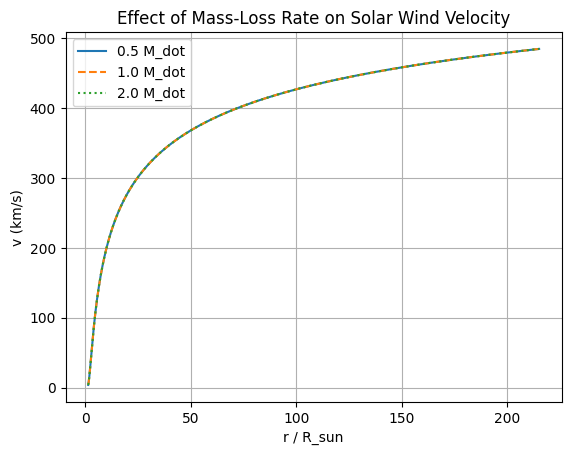

In [62]:
# Solucion de velocidad para T = 1 MK hasta 1 AU
r_mdot, v_mdot = solve_parker_wind(1e6,r_max=215)

plt.plot(r_mdot/R_sun,v_mdot/1000,label="0.5 M_dot")
plt.plot(r_mdot/R_sun,v_mdot/1000,"--",label="1.0 M_dot")
plt.plot(r_mdot/R_sun,v_mdot/1000,":",label="2.0 M_dot")

plt.xlabel("r / R_sun")
plt.ylabel("v (km/s)")
plt.title("Effect of Mass-Loss Rate on Solar Wind Velocity")
plt.legend()
plt.grid()

plt.show()

In [63]:
rho_mdot_05 = M_dot_05/(4*np.pi*r_mdot**2*v_mdot)
rho_mdot_10 = M_dot_10/(4*np.pi*r_mdot**2*v_mdot)
rho_mdot_20 = M_dot_20/(4*np.pi*r_mdot**2*v_mdot)

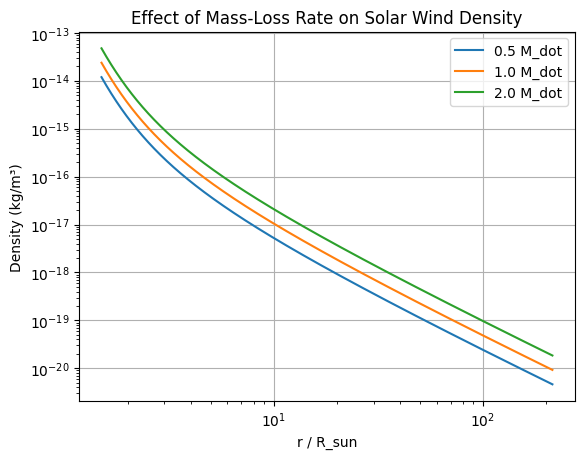

In [64]:
plt.loglog(r_mdot/R_sun,rho_mdot_05,label="0.5 M_dot")
plt.loglog(r_mdot/R_sun,rho_mdot_10,label="1.0 M_dot")
plt.loglog(r_mdot/R_sun,rho_mdot_20,label="2.0 M_dot")

plt.xlabel("r / R_sun")
plt.ylabel("Density (kg/m³)")
plt.title("Effect of Mass-Loss Rate on Solar Wind Density")
plt.legend()
plt.grid()

plt.show()

In [65]:
print("rho(0.5 M_dot) / rho(M_dot) =",rho_mdot_05[-1]/rho_mdot_10[-1])
print("rho(2 M_dot) / rho(M_dot) =",rho_mdot_20[-1]/rho_mdot_10[-1])

rho(0.5 M_dot) / rho(M_dot) = 0.5
rho(2 M_dot) / rho(M_dot) = 2.0


In [66]:
# Radio de 1 AU
r_AU = 215*R_sun

# Velocidad exactamente en 1 AU
v_1AU = velocidad_interpolada(r_mdot,v_mdot,r_AU)

# Densidades en 1 AU
rho_05_1AU = M_dot_05/(4*np.pi*r_AU**2*v_1AU)
rho_10_1AU = M_dot_10/(4*np.pi*r_AU**2*v_1AU)
rho_20_1AU = M_dot_20/(4*np.pi*r_AU**2*v_1AU)

print(f"v(1 AU) = {v_1AU/1000} km/s")
print()
print(f"rho(0.5 M_dot) = {rho_05_1AU} kg/m^3")
print(f"rho(1.0 M_dot) = {rho_10_1AU} kg/m^3")
print(f"rho(2.0 M_dot) = {rho_20_1AU} kg/m^3")

v(1 AU) = 484.68558748236154 km/s

rho(0.5 M_dot) = 4.621313670498113e-21 kg/m^3
rho(1.0 M_dot) = 9.242627340996226e-21 kg/m^3
rho(2.0 M_dot) = 1.8485254681992452e-20 kg/m^3


### Effect of Mass-Loss Rate on the Solar Wind

The mass-loss rate determines the amount of plasma transported outward by the solar wind. From the continuity equation,

$$
4\pi r^2\rho v=\dot{M},
$$

the density can be written as

$$
\rho(r)=\frac{\dot{M}}{4\pi r^2v(r)}.
$$

To study the effect of the mass-loss rate, the temperature was fixed at

$$
T=10^6\ \mathrm{K},
$$

and three values were considered:

$$
0.5\dot{M}_0,\qquad
\dot{M}_0,\qquad
2\dot{M}_0,
$$

where

$$
\dot{M}_0=2\times10^{-14}M_\odot\,\mathrm{yr}^{-1}
\approx1.26\times10^9\ \mathrm{kg/s}.
$$

The numerical velocity profiles for the three mass-loss rates overlap exactly. This occurs because $\dot{M}$ does not appear explicitly in the Parker velocity equation,

$$
\frac{dv}{dr}
=
\frac{
\frac{2v_c^2}{r}-\frac{GM_\odot}{r^2}
}{
v-\frac{v_c^2}{v}
}.
$$

Therefore, for a fixed temperature, changing the mass-loss rate does not modify the velocity solution $v(r)$ in the isothermal Parker model.

In contrast, the density depends directly on $\dot{M}$. Since $r$ and $v(r)$ are unchanged,

$$
\rho\propto\dot{M}.
$$

The numerical results confirm this relation. At every radial position,

$$
\frac{\rho_{0.5\dot{M}_0}}{\rho_{\dot{M}_0}}=0.5,
$$

while

$$
\frac{\rho_{2\dot{M}_0}}{\rho_{\dot{M}_0}}=2.
$$

Thus, reducing the mass-loss rate by a factor of two reduces the density by the same factor, while doubling the mass-loss rate doubles the density.

The advective acceleration,

$$
v\frac{dv}{dr},
$$

is determined by the dynamical balance between the pressure gradient and solar gravity. Although changing the mass-loss rate modifies the density of the wind, $\dot{M}$ cancels when the continuity equation is combined with the momentum equation to derive the Parker wind equation. Therefore, for a fixed temperature, changing $\dot{M}$ does not alter the advective acceleration or the resulting velocity profile. Instead, the density adjusts proportionally to $\dot{M}$ in order to maintain mass conservation.

At

$$
1\ \mathrm{AU}\approx215R_\odot,
$$

the numerical results are:

| $\dot{M}/\dot{M}_0$ | $v(1\,\mathrm{AU})$ (km/s) | $\rho(1\,\mathrm{AU})$ (kg/m$^3$) |
|---:|---:|---:|
| $0.5$ | $484.69$ | $4.62\times10^{-21}$ |
| $1.0$ | $484.69$ | $9.24\times10^{-21}$ |
| $2.0$ | $484.69$ | $1.85\times10^{-20}$ |

These results clearly separate the roles of temperature and mass-loss rate in the model. The temperature determines the dynamical velocity solution through the Parker equation, whereas the mass-loss rate determines the density required to maintain the corresponding mass flux.

Therefore, within the isothermal Parker model,

$$
\boxed{v(r)\ \text{is independent of}\ \dot{M}}
$$

for fixed temperature, while

$$
\boxed{\rho(r)\propto\dot{M}}.
$$

## 9. Coronal Heating Extension

The previous Parker wind model assumes an isothermal corona without an explicit additional heating term. As an extension, a radially decreasing heating contribution is introduced into the wind equation.

The modified equation is

$$
\frac{dv}{dr}
=
\frac{
\frac{2v_c^2}{r}
-\frac{GM_\odot}{r^2}
+\frac{Q(r)}{v}
}{
v-\frac{v_c^2}{v}
},
$$

where the heating function is defined as

$$
Q(r)=Q_0e^{-r/H},
$$

with a characteristic heating scale

$$
H=5R_\odot.
$$

The exponential form represents a heating contribution that is stronger close to the Sun and decreases with radial distance.

The parameter $Q_0$ controls the strength of the additional heating. In this experiment, $Q_0$ will be adjusted numerically until the terminal wind velocity is approximately 20% larger than in the solution without additional heating.

The baseline temperature is fixed at

$$
T=10^6\ \mathrm{K},
$$

and the modified equation is integrated using the RK4 method.

In [67]:
# Escala espacial del calentamiento
H = 5*R_sun

def Q(r,Q_0):
  return Q_0*np.exp(-r/H)

In [68]:
def condicion_critica(r,Q_0,v_c):

  return (2*v_c**2)/r - (G*M_sun)/(r**2) + Q(r,Q_0)/v_c

In [69]:
print(condicion_critica(r_c,0,v_c))

0.0


In [70]:
def biseccion_critica(Q_0,v_c,a,b,tol=1e-6,max_iter=1000):

  for i in range(max_iter):

    c = (a+b)/2

    if abs(condicion_critica(c,Q_0,v_c)) < tol:
      return c

    if condicion_critica(a,Q_0,v_c)*condicion_critica(c,Q_0,v_c) < 0:
      b = c
    else:
      a = c

  return c

In [71]:
r_c_prueba = biseccion_critica(
    0,
    v_c,
    1*R_sun,
    20*R_sun
)

print(f"Radio critico original: {r_c/R_sun} R_sun")
print(f"Radio critico por biseccion: {r_c_prueba/R_sun} R_sun")

Radio critico original: 5.776779249267315 R_sun
Radio critico por biseccion: 5.776778817176819 R_sun


### Dimensional Analysis of the Heating Term

Before selecting the heating amplitude $Q_0$, its units can be determined from the modified Parker equation.

The terms in the numerator must have dimensions of acceleration,

$$
\left[\frac{v_c^2}{r}\right]
=
\left[\frac{GM_\odot}{r^2}\right]
=
\mathrm{m\,s^{-2}}.
$$

Therefore,

$$
\left[\frac{Q(r)}{v}\right]
=
\mathrm{m\,s^{-2}}.
$$

Since velocity has units of $\mathrm{m\,s^{-1}}$,

$$
[Q]
=
\mathrm{m^2\,s^{-3}}.
$$

Thus, the heating amplitude has units

$$
\boxed{
[Q_0]=\mathrm{m^2\,s^{-3}}
}.
$$

These units are equivalent to $\mathrm{J\,kg^{-1}\,s^{-1}}$, corresponding dimensionally to an energy input rate per unit mass.

In [72]:
v_base = v_10_1AU

v_objetivo = 1.2*v_base

print(f"Velocidad base: {v_base/1000} km/s")
print(f"Velocidad objetivo: {v_objetivo/1000} km/s")

Velocidad base: 484.68558748236154 km/s
Velocidad objetivo: 581.6227049788338 km/s


In [73]:
def parker_ode_heating(r,v,v_c,Q_0):

  Q_r = Q_0*np.exp(-r/H)

  numerador = (2*v_c**2)/r - (G*M_sun)/(r**2) + Q_r/v
  denominador = v - (v_c**2)/v

  return numerador/denominador

In [74]:
def rk4_heating(r_0,v_0,r_final,h,v_c,Q_0):

  r_valores = [r_0]
  v_valores = [v_0]

  r_actual = r_0
  v_actual = v_0

  if r_final < r_0:
    h = -abs(h)
  else:
    h = abs(h)

  while (h > 0 and r_actual < r_final) or (h < 0 and r_actual > r_final):

    k1 = h*parker_ode_heating(r_actual,v_actual,v_c,Q_0)

    k2 = h*parker_ode_heating(
        r_actual+h/2,
        v_actual+k1/2,
        v_c,
        Q_0
    )

    k3 = h*parker_ode_heating(
        r_actual+h/2,
        v_actual+k2/2,
        v_c,
        Q_0
    )

    k4 = h*parker_ode_heating(
        r_actual+h,
        v_actual+k3,
        v_c,
        Q_0
    )

    v_nuevo = v_actual + (k1+2*k2+2*k3+k4)/6
    r_nuevo = r_actual + h

    r_valores.append(r_nuevo)
    v_valores.append(v_nuevo)

    r_actual = r_nuevo
    v_actual = v_nuevo

  return np.array(r_valores), np.array(v_valores)

In [75]:
def solve_parker_wind_heating(T,Q_0,r_min=1.5,r_max=215,h=1e6):

  # Velocidad critica
  v_c = np.sqrt((k_B*T)/(mu*m_p))

  # Nuevo radio critico
  r_c_Q = biseccion_critica(
      Q_0,
      v_c,
      1*R_sun,
      20*R_sun
  )

  # Perturbaciones alrededor del punto critico
  epsilon_r = 1e-3*r_c_Q
  epsilon_v = 1e-3*v_c

  # Rama subsonica
  r_sub_0 = r_c_Q - epsilon_r
  v_sub_0 = v_c - epsilon_v

  # Rama supersonica
  r_sup_0 = r_c_Q + epsilon_r
  v_sup_0 = v_c + epsilon_v

  # Limites del dominio
  r_min_m = r_min*R_sun
  r_max_m = r_max*R_sun

  # Integracion RK4
  r_sub, v_sub = rk4_heating(
      r_sub_0,v_sub_0,r_min_m,h,v_c,Q_0
  )

  r_sup, v_sup = rk4_heating(
      r_sup_0,v_sup_0,r_max_m,h,v_c,Q_0
  )

  # Unir las dos ramas
  r = np.concatenate((r_sub[::-1],[r_c_Q],r_sup))
  v = np.concatenate((v_sub[::-1],[v_c],v_sup))

  return r,v,r_c_Q

In [76]:
r_test, v_test, r_c_test = solve_parker_wind_heating(
    1e6,
    0
)

r_AU = 215*R_sun

v_test_1AU = velocidad_interpolada(
    r_test,
    v_test,
    r_AU
)

print(f"Radio critico = {r_c_test/R_sun} R_sun")
print(f"Velocidad a 1 AU = {v_test_1AU/1000} km/s")
print(f"Velocidad anterior = {v_base/1000} km/s")

Radio critico = 5.776778817176819 R_sun
Velocidad a 1 AU = 484.685587487832 km/s
Velocidad anterior = 484.68558748236154 km/s


In [79]:
Q_0_valores = [7e6,8e6,9e6,1e7]

for Q_0 in Q_0_valores:

  r_Q, v_Q, r_c_Q = solve_parker_wind_heating(
      1e6,
      Q_0
  )

  v_Q_1AU = velocidad_interpolada(
      r_Q,
      v_Q,
      r_AU
  )

  aumento = (v_Q_1AU-v_base)/v_base*100

  print(f"Q_0 = {Q_0}")
  print(f"r_c = {r_c_Q/R_sun} R_sun")
  print(f"v(1 AU) = {v_Q_1AU/1000} km/s")
  print(f"Aumento = {aumento} %")
  print()

Q_0 = 7000000.0
r_c = 2.1991438195109367 R_sun
v(1 AU) = 567.332564285498 km/s
Aumento = 17.05166791371615 %

Q_0 = 8000000.0
r_c = 2.0672408249229193 R_sun
v(1 AU) = 577.1595591107197 km/s
Aumento = 19.079166787009825 %

Q_0 = 9000000.0
r_c = 1.9561311285942793 R_sun
v(1 AU) = 586.614005642892 km/s
Aumento = 21.02980175044712 %

Q_0 = 10000000.0
r_c = 1.8609263803809881 R_sun
v(1 AU) = 595.7310061194539 km/s
Aumento = 22.91081507372726 %



In [80]:
def buscar_Q_0(Q_a,Q_b,tol=1e-3,max_iter=50):

  for i in range(max_iter):

    Q_c = (Q_a+Q_b)/2

    r_Q, v_Q, r_c_Q = solve_parker_wind_heating(
        1e6,
        Q_c
    )

    v_Q_1AU = velocidad_interpolada(
        r_Q,
        v_Q,
        r_AU
    )

    error = v_Q_1AU-v_objetivo

    if abs(error) < tol:
      return Q_c, r_c_Q, v_Q_1AU

    if v_Q_1AU < v_objetivo:
      Q_a = Q_c
    else:
      Q_b = Q_c

  return Q_c, r_c_Q, v_Q_1AU

In [81]:
Q_0_final, r_c_final, v_final = buscar_Q_0(
    8e6,
    9e6
)

aumento_final = (v_final-v_base)/v_base*100

print(f"Q_0 = {Q_0_final} m^2/s^3")
print(f"r_c = {r_c_final/R_sun} R_sun")
print(f"v(1 AU) = {v_final/1000} km/s")
print(f"Aumento = {aumento_final} %")

Q_0 = 8467402.935028076 m^2/s^3
r_c = 2.013059401884675 R_sun
v(1 AU) = 581.6227041628918 km/s
Aumento = 19.99999983165538 %


In [82]:
# Solucion sin calentamiento
r_base, v_base_perfil = solve_parker_wind(
    1e6,
    r_max=215
)

# Solucion con calentamiento
r_heating, v_heating, r_c_heating = solve_parker_wind_heating(
    1e6,
    Q_0_final,
    r_max=215
)

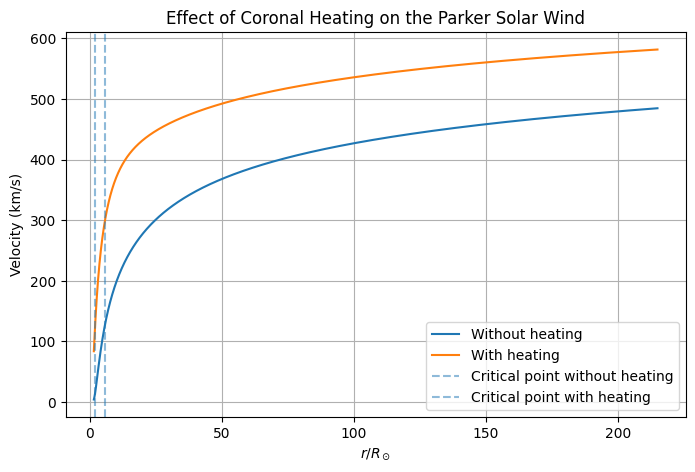

In [83]:
plt.figure(figsize=(8,5))

plt.plot(
    r_base/R_sun,
    v_base_perfil/1000,
    label="Without heating"
)

plt.plot(
    r_heating/R_sun,
    v_heating/1000,
    label="With heating"
)

plt.axvline(
    r_c/R_sun,
    linestyle="--",
    alpha=0.5,
    label="Critical point without heating"
)

plt.axvline(
    r_c_heating/R_sun,
    linestyle="--",
    alpha=0.5,
    label="Critical point with heating"
)

plt.xlabel(r"$r/R_\odot$")
plt.ylabel("Velocity (km/s)")
plt.title("Effect of Coronal Heating on the Parker Solar Wind")

plt.legend()
plt.grid()

plt.show()

### Effect of Coronal Heating and the Role of Advection

The additional heating term produces a significant modification of the solar wind solution. The value

$$
Q_0 = 8.4674\times10^6\ \mathrm{m^2\,s^{-3}}
$$

was obtained numerically by adjusting the heating amplitude until the wind velocity at 1 AU increased by approximately 20%.

The results are

| Model | $r_c$ ($R_\odot$) | $v(1\,\mathrm{AU})$ (km/s) |
|---|---:|---:|
| Without additional heating | $5.777$ | $484.69$ |
| With additional heating | $2.013$ | $581.62$ |

Therefore,

$$
\frac{581.62-484.69}{484.69}\times100
\approx20\%.
$$

The additional heating has two main effects. First, the critical point moves closer to the Sun, indicating that the transition from subsonic to supersonic flow occurs at a smaller radial distance. Second, the wind reaches a larger velocity throughout the supersonic region and consequently a larger terminal velocity.

The heating function,

$$
Q(r)=Q_0e^{-r/H},
$$

with

$$
H=5R_\odot,
$$

is strongest close to the Sun and decreases exponentially with distance. Therefore, most of the additional energy is supplied in the inner region of the solar wind.

Advection plays an important role in the response of the flow to this additional energy. The term

$$
v\frac{dv}{dr}
$$

represents the transport of momentum associated with the outward-moving plasma. The additional heating modifies the acceleration of the wind close to the Sun, while advection describes how the accelerating flow carries this dynamical response outward.

As the velocity increases, the advective term becomes increasingly important in the momentum balance. Consequently, even though the heating function decreases rapidly with radial distance, the wind continues to accelerate beyond the region where the additional heating is strongest.

The numerical experiment therefore illustrates the interplay between energy input and advection: localized coronal heating produces stronger acceleration in the inner region, shifts the sonic transition closer to the Sun, and the resulting faster flow advects this dynamical effect outward, producing a larger terminal solar-wind velocity.

## 10. Conclusions

In this project, the Parker solar wind model was studied analytically and numerically as an application of ordinary differential equations to astrophysical fluid dynamics. Starting from the momentum and continuity equations under the assumptions of steady, spherically symmetric, and isothermal flow, the Parker wind equation was obtained and its critical point was analyzed.

For a coronal temperature of

$$
T=10^6\ \mathrm{K},
$$

the critical velocity and radius were found to be approximately

$$
v_c=128.49\ \mathrm{km/s},
\qquad
r_c=5.78R_\odot.
$$

The semi-analytical solution obtained from the integrated Parker equation provided a reference solution for evaluating the numerical methods. Euler and fourth-order Runge--Kutta methods were implemented manually to integrate the differential equation across its subsonic and supersonic branches. At $50R_\odot$, RK4 reproduced the reference solution with substantially smaller relative error than Euler. The step-size experiments also showed the expected first-order behavior of Euler, while the RK4 errors reached a numerical floor associated with other approximations in the calculation, including the treatment of the critical point and interpolation.

The temperature study showed that hotter coronal conditions produce larger critical velocities, move the critical point closer to the Sun, and generate faster solar winds. At 1 AU, the calculated velocities were approximately

$$
305.92,\quad 484.69,\quad 752.16\ \mathrm{km/s}
$$

for temperatures of $0.5$, $1.0$, and $2.0$ MK, respectively. For a fixed mass-loss rate, the corresponding density decreases when the wind velocity increases.

The mass-loss-rate experiment demonstrated that $\dot{M}$ does not determine the velocity profile in the isothermal Parker equation. Changing $\dot{M}$ by factors of $0.5$ and $2$ left $v(r)$ unchanged, while the density varied linearly according to

$$
\rho(r)=\frac{\dot{M}}{4\pi r^2v(r)}.
$$

This illustrates the different roles of the dynamical velocity equation and mass conservation in determining the properties of the solar wind.

Finally, an exponentially decreasing coronal heating term was incorporated into the model. A heating amplitude of approximately

$$
Q_0=8.47\times10^6\ \mathrm{m^2\,s^{-3}}
$$

increased the velocity at 1 AU from

$$
484.69\ \mathrm{km/s}
$$

to

$$
581.62\ \mathrm{km/s},
$$

corresponding to an increase of approximately $20\%$. The additional heating also shifted the critical point from approximately $5.78R_\odot$ to $2.01R_\odot$.

Overall, the numerical experiments illustrate how the Parker model connects gravity, pressure-driven acceleration, advection, mass conservation, and coronal heating. They also show the importance of numerical treatment near the critical point and the advantages of higher-order integration methods such as RK4 for solving astrophysical ODEs.